In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn

print("numpy      ", np.__version__)
print("matplotlib ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)

In [ ]:
# Plot styling - cosmetic onnly, safe to ignore
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110

# A fixed random generator, so your numbers match the text.
# Change the seed to see different random draws.
rng = np.random.default_rng(seed=67)

---
# Part 1 — NumPy essentials for machine learning

NumPy is the reason Python is usable for machine learning. It gives you the
**array**: a grid of numbers that you can do arithmetic on all at once.

You only need a handful of NumPy ideas for everything that follows:

1. arrays and their **shape**
2. **vectorized** arithmetic (no Python loops)
3. **matrix multiplication**, `@`
4. **broadcasting**

Let's take them one at a time.

## 1.1 Arrays and shapes

An array is a grid of numbers. Its `.shape` tells you how big the grid is, as a
tuple: `(rows, columns)`.

**Shape mistakes are the single most common bug in machine learning code.**

In [ ]:
a = np.array([1.0, 2.0, 3.0])  # 1D: a vector of 3 numbers
b = np.array(
    [
        [1.0, 2.0, 3.0],  # 2D: 2 rows, 3 columns
        [4.0, 5.0, 6.0]
    ]
)

print("a =", a)
print("a.shape =", a.shape) # (3,)   -> 1D, length 3
print()
print("b =")
print(b)
print("b.shape =", b.shape)  # (2, 3)  -> 2 rows, 3 columns

In [ ]:
row = np.array([[1.0, 2.0, 3.0]])  # note the double brackets
col = np.array([[1.0], [2.0], [3.0]])

print("a   shape", a.shape, "  <- 1D, no orientation")
print("row shape", row.shape, "<- 2D, one row")
print("col shape", col.shape, "<- 2D, one column")

# reshape(-1, 1) is the idiom for "make this a single column"
# The -1 means "work the size out for me"
print()
print("a.reshape(-1, 1) shape:", a.reshape(-1, 1).shape)

### Our data layout convention

Throughout all four notebooks we store data as a 2D array with:

- **one row per example** (one flower, one image, one customer)
- **one column per feature** (petal length, pixel brightness, age)

So `X.shape == (n_samples, n_features)`. This is the standard convention in
scikit-learn and PyTorch alike, and sticking to it prevents most shape confusion.

In [ ]:
# 5 examples, 2 features each.
X = rng.normal(size=(5, 2))
print(X)
print("X.shape =", X.shape, "-> 5 examples, 2 features")

## 1.2 Vectorized arithmetic

Arithmetic on arrays happens **element by element**, across the whole array at once.
No loop required. This matters for two reasons: the code is shorter, and it runs
one or two orders of magnitude faster, because the loop happens in compiled C rather
than in Python.

In [ ]:
x = np.array([1.0, 2.0, 3.0, 4.0])

print("x + 10  = ", x + 10) # adds 10 to every element
print("x * 2   =", x * 2)
print("x ** 2  =", x**2)
print("x > 2.5 =", x > 2.5)  # elementwise comparison -> array of True/False
print()
print("np.exp(x)  =", np.exp(x)) # e to the power of each element
print("np.mean(x) =", np.mean(x)) # collapses the array to one number
print("np.sum(x)  =", np.sum(x)) 

Here is the same computation written both ways, so you can see the speed difference
for yourself. One million numbers, squared.

In [ ]:
import time

big = rng.normal(size=1_000_000)

t0 = time.perf_counter()
result_loop = [v**2 for v in big]  # the Python way
t1 = time.perf_counter()
result_vec = big**2  # the NumPy way
t2 = time.perf_counter()

print(f"Python loop : {t1 - t0:.4f} s")
print(f"NumPy       : {t2 - t1:.4f} s")
print(f"speed-up    : {(t1 - t0) / (t2 - t1):.0f}x")

**Rule of thumb:** if you are writing a `for` loop over data points in NumPy code,
there is almost always a vectorized way to do it instead. The one loop we *will*
keep is the loop over training steps, because each step genuinely depends on the one
before it.

## 1.3 Matrix multiplication — the `@` operator

This is the operation at the heart of every neural network, so it is worth a minute.

Matrix multiplication combines two arrays by taking **rows of the first against
columns of the second**. For each output entry, you multiply the matching numbers
pairwise and add them up.

The shape rule is the only thing you have to remember:

```
(n, k) @ (k, m)  ->  (n, m)
      ^^^^^^^  these must match; they cancel out
```

The inner numbers must be equal, and they disappear from the result.

In [ ]:
A_ = np.array([[1.0, 2.0],
               [3.0, 4.0],
               [5.0, 6.0]])  # (3, 2)

B_ = np.array([[10.0, 20.0, 30.0, 40.0],
               [50.0, 60.0, 70.0, 80.0]])  # (2, 4)

C_ = A_ @ B_

print("A_ shape", A_.shape)
print("B_ shape", B_.shape)
print("C_ shape", C_.shape, "<- (3,2) @ (2,4) -> (3,4)")
print()
print(C_)

## 1.4 Broadcasting

Broadcasting is NumPy stretching a smaller array to fit a bigger one, automatically,
without copying any memory.

We need it because of the **bias**: every unit in a layer has one bias number, and it
has to be added to that unit's output for *every* example in the batch. Broadcasting
does that for us.

In [49]:
Z = rng.normal(size=(5, 3))
b = np.array([100.0, 200.0, 300.0])  # one bias per unit, shape (3,)

print("Z shape", Z.shape, "+ b shape", b.shape, "->", (Z + b).shape)
print()
print(np.round(Z + b, 2))

Z shape (5, 3) + b shape (3,) -> (5, 3)

[[100.24 199.48 300.06]
 [101.92 199.69 301.04]
 [ 99.12 199.95 300.1 ]
 [101.11 198.82 299.4 ]
 [100.01 200.35 300.05]]


---
# Part 2 — A single neuron

A neuron is a small function. It takes some numbers in, and puts one number out. It
does this in two steps:

**Step 1 — weighted sum.** Multiply each input by a *weight*, add them up, then add a
*bias*:

$$z = x_1 w_1 + x_2 w_2 + \dots + b$$

The weights say how much each input matters. A large positive weight means "this
input pushes the answer up"; a large negative weight means "this input pushes it
down"; a weight near zero means "ignore this input". The bias shifts the whole thing
up or down regardless of the inputs.

**Step 2 — activation.** Pass `z` through a squashing function `a = f(z)`.

The weights and the bias are the **parameters** — the numbers that get *learned*.
Everything else about the network is fixed by us in advance.

In [51]:
def neuron(x, w, b):
    """One neuron
    
    x: inputs, shape (n_features,)
    w: weights, shape (n_features,)
    b: bias, a single number

    Returns the weighted sum z
    """
    return x @ w + b

x = np.array([2.0, 3.0])
w = np.array([0.5, -1.0]) 
b = 1.0

print("z =", neuron(x, w, b))
print("by hand:", 2.0 * 0.5 + 3.0 * -1.0 + 1.0)

z = -1.0
by hand: -1.0


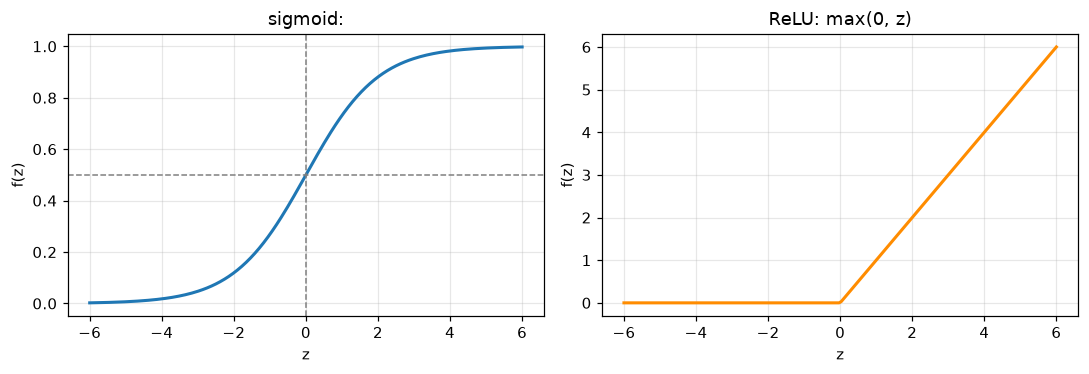

In [55]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0.0, z)

zs = np.linspace(-6, 6, 200)

# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(zs, sigmoid(zs), linewidth=2)
axes[0].axhline(0.5, linestyle="--", linewidth=1, color="gray")
axes[0].axvline(0.0, linestyle="--", linewidth=1, color="gray")
axes[0].set_title("sigmoid:")
axes[0].set_xlabel("z"); axes[0].set_ylabel("f(z)")

axes[1].plot(zs, relu(zs), linewidth=2, color="darkorange")
axes[1].set_title("ReLU: max(0, z)")
axes[1].set_xlabel("z"); axes[1].set_ylabel("f(z)")

plt.tight_layout()
plt.show()